# Carga inicial del dataset de tweets


In [2]:
import pandas as pd

df = pd.read_csv("../data/tweets.csv")
print(df.shape)

(52542, 10)


In [3]:
print(list(df.columns))
print()
print(df.dtypes)

['author', 'content', 'country', 'date_time', 'id', 'language', 'latitude', 'longitude', 'number_of_likes', 'number_of_shares']

author                  str
content                 str
country                 str
date_time               str
id                  float64
language                str
latitude            float64
longitude           float64
number_of_likes       int64
number_of_shares      int64
dtype: object


In [4]:
display(df.head())
display(df.tail())

,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares
0,katyperry,Is history repeating itself...?#DONTNORMALIZEH...,NaN,12/01/2017 19:52,8.196330e+17,en,NaN,NaN,7900,3472
1,katyperry,@barackobama Thank you for your incredible gra...,NaN,11/01/2017 08:38,8.191010e+17,en,NaN,NaN,3689,1380
2,katyperry,Life goals. https://t.co/XIn1qKMKQl,NaN,11/01/2017 02:52,8.190140e+17,en,NaN,NaN,10341,2387
3,katyperry,Me right now 🙏🏻 https://t.co/gW55C1wrwd,NaN,11/01/2017 02:44,8.190120e+17,en,NaN,NaN,10774,2458
4,katyperry,SISTERS ARE DOIN' IT FOR THEMSELVES! 🙌🏻💪🏻❤️ ht...,NaN,10/01/2017 05:22,8.186890e+17,en,NaN,NaN,17620,4655


,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares
52537,ddlovato,Life couldn't be better right now. 😊,NaN,06/01/2015 23:10,5.526030e+17,en,NaN,NaN,32799,23796
52538,ddlovato,First Monday back in action. I'd say 21.6 mile...,NaN,06/01/2015 02:17,5.522880e+17,en,NaN,NaN,21709,12511
52539,ddlovato,"Crime shows, buddy, snuggles = the perfect Sun...",NaN,05/01/2015 03:42,5.519470e+17,en,NaN,NaN,25269,15583
52540,ddlovato,❄️ http://t.co/sHCFdPpGPa,NaN,05/01/2015 00:06,5.518920e+17,und,NaN,NaN,15985,10456
52541,ddlovato,❤️❄️✈️ http://t.co/ixmB5lv17Z,NaN,05/01/2015 00:02,5.518910e+17,und,NaN,NaN,16193,10822


In [5]:
print("Valores nulos por columna:")
df.isna().sum()

Valores nulos por columna:


author                  0
content                 0
country             52506
date_time               0
id                      0
language                0
latitude            52541
longitude           52541
number_of_likes         0
number_of_shares        0
dtype: int64

In [6]:
print("Valores únicos por columna:")
df.nunique()

Valores únicos por columna:


author                 20
content             52425
country                 2
date_time           49590
id                  43641
language               32
latitude                1
longitude               1
number_of_likes     19572
number_of_shares    14599
dtype: int64

In [7]:
df.describe()

,id,latitude,longitude,number_of_likes,number_of_shares
count,5.254200e+04,1.000000,1.000000,52542.000000,52542.000000
mean,5.741141e+17,37.776973,-122.416523,9637.838339,5386.880857
std,2.009723e+17,NaN,NaN,18759.083482,11517.259484
min,6.789717e+09,37.776973,-122.416523,0.000000,0.000000
25%,4.485852e+17,37.776973,-122.416523,916.000000,378.000000
50%,6.337935e+17,37.776973,-122.416523,2595.500000,1266.000000
75%,7.336588e+17,37.776973,-122.416523,10300.750000,5205.000000
max,8.237200e+17,37.776973,-122.416523,429159.000000,219062.000000


In [8]:
print("Autores con más tweets:")
print(df["author"].value_counts().head(10))
print()
print("Idiomas:")
print(df["language"].value_counts().head(10))

Autores con más tweets:
author
TheEllenShow     3147
jimmyfallon      3123
ArianaGrande     3104
YouTube          3077
KimKardashian    2939
katyperry        2924
selenagomez      2913
rihanna          2877
BarackObama      2863
britneyspears    2776
Name: count, dtype: int64

Idiomas:
language
en     46934
und     3242
es      1372
pt       180
fr       118
tl       113
in       108
et        61
nl        51
it        50
Name: count, dtype: int64


## Limpieza y preprocesamiento
1. Duplicados (por autor + contenido + fecha).
2. Tipos: `date_time` a datetime, numericas y texto.
3. Nulos: se quita `content`/fecha vacios; `country`/`language` -> `unknown`; likes/shares -> 0.
4. Texto: se extraen menciones, hashtags y URLs; `content_clean` + metricas.
5. Fecha: `year`, `month`, `hour`, `weekday`, `engagement`.
6. Se exporta `data/tweets_clean.csv`.

In [9]:
import re

df_clean = df.copy()

# Duplicados 
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.drop_duplicates(subset=["author", "content", "date_time"])
print("Filas:", len(df), "->", len(df_clean))

Filas: 52542 -> 52542


In [10]:
# Tipos de datos
df_clean["date_time"] = pd.to_datetime(
    df_clean["date_time"], format="%d/%m/%Y %H:%M", errors="coerce"
)
for c in ["latitude", "longitude", "number_of_likes", "number_of_shares"]:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")
for c in ["author", "content", "language", "country"]:
    df_clean[c] = df_clean[c].astype("string").str.strip()

df_clean.dtypes

author                      string
content                     string
country                     string
date_time           datetime64[us]
id                         float64
language                    string
latitude                   float64
longitude                  float64
number_of_likes              int64
number_of_shares             int64
dtype: object

In [11]:
# Nulos
df_clean = df_clean[df_clean["content"].notna() & (df_clean["content"] != "")]
df_clean = df_clean[df_clean["date_time"].notna()]
df_clean["country"] = df_clean["country"].fillna("unknown")
df_clean["language"] = df_clean["language"].fillna("unknown")
df_clean["number_of_likes"] = df_clean["number_of_likes"].fillna(0).astype("int64")
df_clean["number_of_shares"] = df_clean["number_of_shares"].fillna(0).astype("int64")

print(df_clean.isna().sum())
print("Filas:", len(df_clean))

author                  0
content                 0
country                 0
date_time               0
id                      0
language                0
latitude            52541
longitude           52541
number_of_likes         0
number_of_shares        0
dtype: int64
Filas: 52542


In [12]:
# Texto: extraer entidades y limpiar
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@(\w+)")
HASHTAG_RE = re.compile(r"#(\w+)")

df_clean["mentions"] = df_clean["content"].str.findall(MENTION_RE)
df_clean["hashtags"] = df_clean["content"].str.findall(HASHTAG_RE)
df_clean["has_url"] = df_clean["content"].str.contains(URL_RE)

def limpiar(t):
    t = URL_RE.sub("", t)
    t = MENTION_RE.sub("", t)
    t = HASHTAG_RE.sub(r"\1", t)          
    t = t.replace("&amp;", "&").replace("&lt;", "<").replace("&gt;", ">")
    return re.sub(r"\s+", " ", t).strip().lower()

df_clean["content_clean"] = df_clean["content"].apply(limpiar)
df_clean = df_clean[df_clean["content_clean"] != ""]

df_clean["text_length"] = df_clean["content_clean"].str.len()
df_clean["word_count"] = df_clean["content_clean"].str.split().str.len()
df_clean["n_hashtags"] = df_clean["hashtags"].str.len()

df_clean[["content", "content_clean", "hashtags", "has_url"]].head()

,content,content_clean,hashtags,has_url
0,Is history repeating itself...?#DONTNORMALIZEH...,is history repeating itself...?dontnormalizehate,[DONTNORMALIZEHATE],True
1,@barackobama Thank you for your incredible gra...,thank you for your incredible grace in leaders...,[],True
2,Life goals. https://t.co/XIn1qKMKQl,life goals.,[],True
3,Me right now 🙏🏻 https://t.co/gW55C1wrwd,me right now 🙏🏻,[],True
4,SISTERS ARE DOIN' IT FOR THEMSELVES! 🙌🏻💪🏻❤️ ht...,sisters are doin' it for themselves! 🙌🏻💪🏻❤️,[],True


In [13]:
# Variables temporales + engagement
df_clean["year"] = df_clean["date_time"].dt.year
df_clean["month"] = df_clean["date_time"].dt.month
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["weekday"] = df_clean["date_time"].dt.day_name()
df_clean["engagement"] = df_clean["number_of_likes"] + df_clean["number_of_shares"]

df_clean = df_clean.sort_values("date_time").reset_index(drop=True)
print("Shape final:", df_clean.shape)
df_clean.head()

Shape final: (52257, 22)


,author,content,country,date_time,id,language,latitude,longitude,number_of_likes,number_of_shares,...,has_url,content_clean,text_length,word_count,n_hashtags,year,month,hour,weekday,engagement
0,Twitter,Twitter's DNS records were temporarily comprom...,unknown,2009-12-18 07:36:00,6.789717e+09,en,NaN,NaN,73,504,...,False,twitter's dns records were temporarily comprom...,118,18,0,2009,12,7,Friday,577
1,Twitter,Update on the DNS issue of last night: http://...,unknown,2009-12-18 21:59:00,6.809736e+09,en,NaN,NaN,55,107,...,True,update on the dns issue of last night:,38,8,0,2009,12,21,Friday,162
2,Twitter,Look! A shiny new blog design. http://blog.twi...,unknown,2009-12-22 18:39:00,6.937397e+09,en,NaN,NaN,53,72,...,True,look! a shiny new blog design. thanks !,39,8,0,2009,12,18,Tuesday,125
3,Twitter,"If you use a Palm Pre, here are some reviews o...",unknown,2009-12-23 17:29:00,6.970825e+09,en,NaN,NaN,40,41,...,True,"if you use a palm pre, here are some reviews o...",95,18,1,2009,12,17,Wednesday,81
4,Twitter,Twitter acquires GeoAPI—location awareness to ...,unknown,2009-12-23 22:38:00,6.979006e+09,en,NaN,NaN,67,104,...,True,twitter acquires geoapi—location awareness to ...,61,7,0,2009,12,22,Wednesday,171


In [15]:
# Guardar CSV limpio
export = df_clean.copy()
export["mentions"] = export["mentions"].str.join("|")
export["hashtags"] = export["hashtags"].str.join("|")

export.to_csv("../data/tweets_clean.csv", index=False, encoding="utf-8")
print("Guardado ../data/tweets_clean.csv", export.shape)

Guardado ../data/tweets_clean.csv (52257, 22)


## EDA

### Tabla resumen de tweets parseados

In [16]:
resumen_cols = [
    "date_time", "author", "content", "content_clean",
    "mentions", "hashtags", "number_of_likes", "number_of_shares",
]
tabla_resumen = df_clean[resumen_cols].copy()
tabla_resumen["mentions"] = tabla_resumen["mentions"].apply(lambda m: ", ".join(m))
tabla_resumen["hashtags"] = tabla_resumen["hashtags"].apply(lambda h: ", ".join(h))
tabla_resumen = tabla_resumen.rename(columns={
    "date_time": "tiempo_de_publicado",
    "author": "autor",
    "content": "tweet",
    "content_clean": "tweet_text_clean",
    "number_of_likes": "likes",
    "number_of_shares": "shares",
})

tabla_resumen.head(10)

,tiempo_de_publicado,autor,tweet,tweet_text_clean,mentions,hashtags,likes,shares
0,2009-12-18 07:36:00,Twitter,Twitter's DNS records were temporarily comprom...,twitter's dns records were temporarily comprom...,,,73,504
1,2009-12-18 21:59:00,Twitter,Update on the DNS issue of last night: http://...,update on the dns issue of last night:,,,55,107
2,2009-12-22 18:39:00,Twitter,Look! A shiny new blog design. http://blog.twi...,look! a shiny new blog design. thanks !,vl,,53,72
3,2009-12-23 17:29:00,Twitter,"If you use a Palm Pre, here are some reviews o...","if you use a palm pre, here are some reviews o...",,appwednesday,40,41
4,2009-12-23 22:38:00,Twitter,Twitter acquires GeoAPI—location awareness to ...,twitter acquires geoapi—location awareness to ...,,,67,104
5,2009-12-28 00:43:00,Twitter,"Sunday Times: ""Why we can never rest: a year i...","sunday times: ""why we can never rest: a year i...",,,121,133
6,2009-12-29 23:54:00,Twitter,Did you know about all of the accounts we have...,did you know about all of the accounts we have...,,,235,54
7,2009-12-30 00:08:00,Twitter,Here's a link to that same list where you won'...,here's a link to that same list where you won'...,,,142,34
8,2009-12-30 19:45:00,Twitter,People are loving @twidroid for Android phones...,people are loving for android phones. do you l...,twidroid,appwednesday,37,46
9,2009-12-30 23:56:00,Twitter,Time is of the essence on New Year's Eve. Foll...,time is of the essence on new year's eve. foll...,timessquarenyc,,53,99


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

n_tweets = len(df_clean)
n_usuarios = df_clean["author"].nunique()

print(f"Total de tweets: {n_tweets}")
print(f"Usuarios unicos: {n_usuarios}")
print(f"Rango de fechas: {df_clean['date_time'].min()} a {df_clean['date_time'].max()}")

Total de tweets: 52257
Usuarios unicos: 20
Rango de fechas: 2009-12-18 07:36:00 a 2017-01-24 02:30:00


### Menciones y hashtags

In [18]:
mentions_all = df_clean["mentions"].explode().dropna()
hashtags_all = df_clean["hashtags"].explode().dropna()

print(f"Total de menciones: {len(mentions_all)}")
print(f"Total de hashtags: {len(hashtags_all)}")

top_mentions = mentions_all.str.lower().value_counts().head(10)
top_hashtags = hashtags_all.str.lower().value_counts().head(10)

print("\nTop 10 menciones:")
print(top_mentions)
print("\nTop 10 hashtags:")
print(top_hashtags)

Total de menciones: 27019
Total de hashtags: 25818

Top 10 menciones:
mentions
jtimberlake     541
katyperry       318
jimmyfallon     254
cristiano       200
rihanna         175
nbcthevoice     148
vevo            139
itunesmusic     133
ofa             117
theellenshow    106
Name: count, dtype: int64

Top 10 hashtags:
hashtags
fallontonight    1079
actonclimate      277
tbt               234
dailyfluff        215
lovetwitter       166
ts1989            165
1                 162
fallonmono        152
confident         149
doyourjob         147
Name: count, dtype: int64


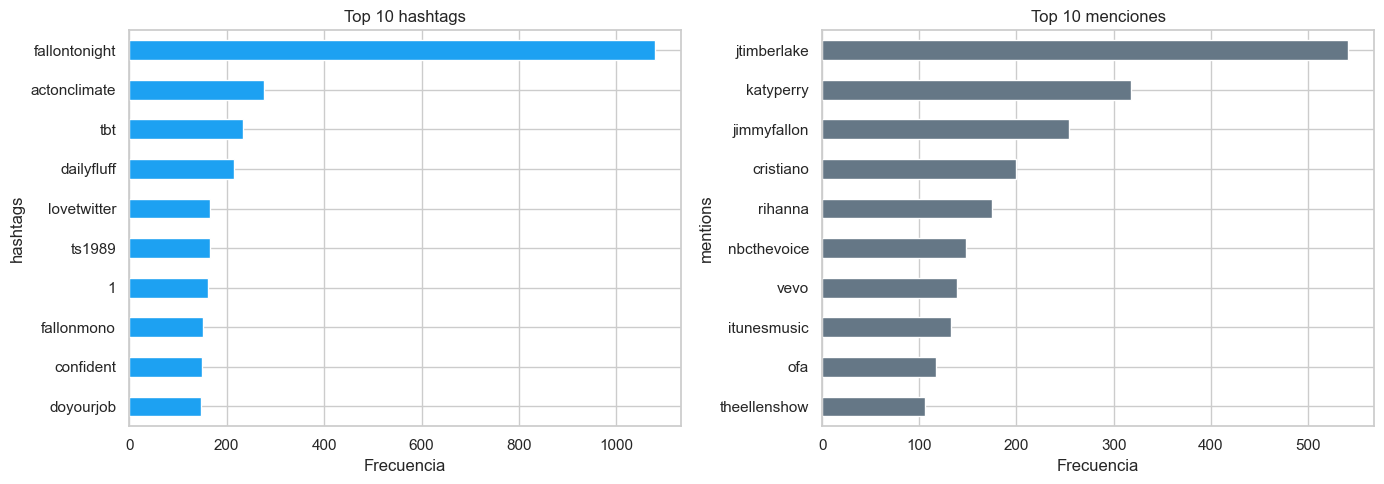

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_hashtags.iloc[::-1].plot(kind="barh", ax=axes[0], color="#1DA1F2")
axes[0].set_title("Top 10 hashtags")
axes[0].set_xlabel("Frecuencia")

top_mentions.iloc[::-1].plot(kind="barh", ax=axes[1], color="#657786")
axes[1].set_title("Top 10 menciones")
axes[1].set_xlabel("Frecuencia")

plt.tight_layout()
plt.show()

### Autores y actividad en el tiempo

Top 10 autores por numero de tweets:
author
TheEllenShow     3147
jimmyfallon      3120
ArianaGrande     3081
YouTube          3073
KimKardashian    2926
katyperry        2908
selenagomez      2868
BarackObama      2863
rihanna          2852
britneyspears    2772
Name: count, dtype: int64[pyarrow]


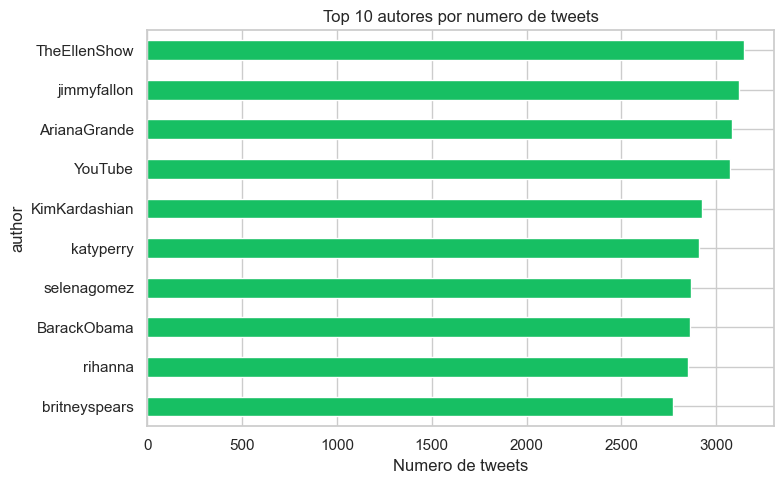

In [20]:
top_autores = df_clean["author"].value_counts().head(10)
print("Top 10 autores por numero de tweets:")
print(top_autores)

fig, ax = plt.subplots(figsize=(8, 5))
top_autores.iloc[::-1].plot(kind="barh", ax=ax, color="#17BF63")
ax.set_title("Top 10 autores por numero de tweets")
ax.set_xlabel("Numero de tweets")
plt.tight_layout()
plt.show()

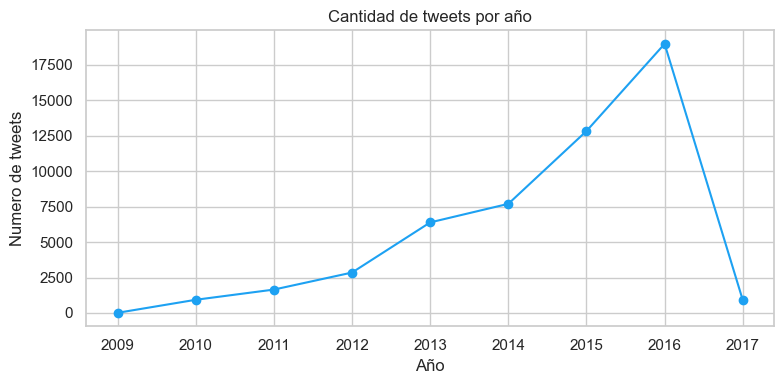

In [21]:
tweets_por_anio = df_clean.groupby("year").size()

fig, ax = plt.subplots(figsize=(8, 4))
tweets_por_anio.plot(kind="line", marker="o", ax=ax, color="#1DA1F2")
ax.set_title("Cantidad de tweets por año")
ax.set_xlabel("Año")
ax.set_ylabel("Numero de tweets")
plt.tight_layout()
plt.show()

## Wordcloud + conclusiones

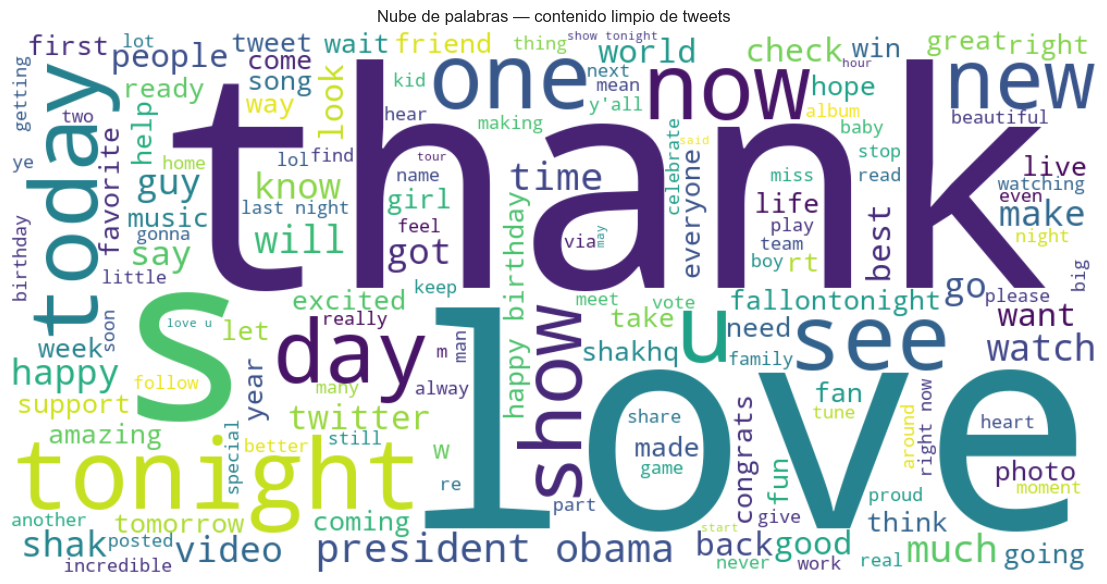

In [22]:
from wordcloud import WordCloud

texto_completo = " ".join(df_clean["content_clean"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150,
    colormap="viridis",
).generate(texto_completo)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — contenido limpio de tweets")
plt.tight_layout()
plt.show()


In [23]:
output_cols = [
    "id", "autor", "tiempo_de_publicado", "anio", "mes", "hora", "dia_semana",
    "tweet", "tweet_texto_limpio",
    "menciones", "hashtags", "n_hashtags",
    "likes", "shares", "engagement",
    "pais", "idioma", "tiene_url", "longitud_texto", "num_palabras",
]

df_output = df_clean.copy()

df_output = df_output.rename(columns={
    "id": "id",
    "author": "autor",
    "date_time": "tiempo_de_publicado",
    "year": "anio",
    "month": "mes",
    "hour": "hora",
    "weekday": "dia_semana",
    "content": "tweet",
    "content_clean": "tweet_texto_limpio",
    "mentions": "menciones",
    "hashtags": "hashtags",
    "n_hashtags": "n_hashtags",
    "number_of_likes": "likes",
    "number_of_shares": "shares",
    "engagement": "engagement",
    "country": "pais",
    "language": "idioma",
    "has_url": "tiene_url",
    "text_length": "longitud_texto",
    "word_count": "num_palabras",
})

df_output["tiempo_de_publicado"] = pd.to_datetime(df_output["tiempo_de_publicado"])

df_output["menciones"] = df_output["menciones"].apply(
    lambda m: "|".join(m) if isinstance(m, list) else m
)
df_output["hashtags"] = df_output["hashtags"].apply(
    lambda h: "|".join(h) if isinstance(h, list) else h
)

df_output = df_output[output_cols].sort_values("tiempo_de_publicado").reset_index(drop=True)

print("Shape df_output:", df_output.shape)
df_output.head()


Shape df_output: (52257, 20)


,id,autor,tiempo_de_publicado,anio,mes,hora,dia_semana,tweet,tweet_texto_limpio,menciones,hashtags,n_hashtags,likes,shares,engagement,pais,idioma,tiene_url,longitud_texto,num_palabras
0,6.789717e+09,Twitter,2009-12-18 07:36:00,2009,12,7,Friday,Twitter's DNS records were temporarily comprom...,twitter's dns records were temporarily comprom...,,,0,73,504,577,unknown,en,False,118,18
1,6.809736e+09,Twitter,2009-12-18 21:59:00,2009,12,21,Friday,Update on the DNS issue of last night: http://...,update on the dns issue of last night:,,,0,55,107,162,unknown,en,True,38,8
2,6.937397e+09,Twitter,2009-12-22 18:39:00,2009,12,18,Tuesday,Look! A shiny new blog design. http://blog.twi...,look! a shiny new blog design. thanks !,vl,,0,53,72,125,unknown,en,True,39,8
3,6.970825e+09,Twitter,2009-12-23 17:29:00,2009,12,17,Wednesday,"If you use a Palm Pre, here are some reviews o...","if you use a palm pre, here are some reviews o...",,appwednesday,1,40,41,81,unknown,en,True,95,18
4,6.979006e+09,Twitter,2009-12-23 22:38:00,2009,12,22,Wednesday,Twitter acquires GeoAPI—location awareness to ...,twitter acquires geoapi—location awareness to ...,,,0,67,104,171,unknown,en,True,61,7


In [24]:
df_output.to_csv("../data/tweets_output.csv", index=False, encoding="utf-8")
print("Guardado ../data/tweets_output.csv", df_output.shape)


Guardado ../data/tweets_output.csv (52257, 20)
